# Meridian - Factor Research Notebook
**QuantConnect Research Environment**

Uses the full 500-stock universe with 5 years of history to run IC analysis and XGBoost feature importance - replacing the 30-ticker standalone analysis that was dominated by momentum regime effects.

**Output:** Revised `GROUP_WEIGHTS` to paste into `factors.py`, backed by ~2,500 observations rather than 30.

**Key question:** Did growth factors genuinely underperform, or was it regime-specific (2022 rate hike drawdown)?

## Cell 1 - Imports and setup

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from scipy import stats
from tqdm import tqdm
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

qb = QuantBook()

STYLE = {
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#0f1117',
    'axes.edgecolor': '#2a2d3a', 'axes.labelcolor': '#c9d1d9',
    'axes.grid': True, 'grid.color': '#2a2d3a', 'grid.linewidth': 0.5,
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'font.family': 'monospace',
}
BLUE  = '#58a6ff'
RED   = '#f78166'
GREEN = '#56d364'
AMBER = '#EF9F27'
MUTED = '#8b949e'

print('Setup complete')

Setup complete


## Cell 2 - Factor definitions and snapshot dates

In [39]:
# Factor definitions: (QC selector string, direction)
# direction: 1 = higher is better, -1 = lower is better
FACTORS = {
    # Value
    'pe_ratio':        ('ValuationRatios.PERatio',                       -1),
    'ev_ebitda':       ('ValuationRatios.EVToEBITDA',                    -1),
    'pb_ratio':        ('ValuationRatios.PBRatio',                       -1),
    'fcf_yield':       ('ValuationRatios.FCFYield',                       1),
    # Quality
    'roe':             ('OperationRatios.ROE.OneYear',                    1),
    'roic':            ('OperationRatios.ROIC.OneYear',                   1),
    'gross_margin':    ('OperationRatios.GrossMargin.OneYear',            1),
    'debt_to_equity':  ('OperationRatios.LongTermDebtEquityRatio.OneYear',-1),
    'income_quality':  ('OperationRatios.FCFNetIncomeRatio.OneYear',      1),
    # Growth
    'revenue_growth':  ('OperationRatios.RevenueGrowth.OneYear',          1),
    'earnings_growth': ('OperationRatios.NetIncomeGrowth.OneYear',        1),
    'fcf_growth':      ('OperationRatios.FCFGrowth.OneYear',              1),
    'ebitda_growth':   ('OperationRatios.OperationIncomeGrowth.OneYear',  1),
}

FACTOR_GROUPS = {
    'value':    ['pe_ratio', 'ev_ebitda', 'pb_ratio', 'fcf_yield'],
    'quality':  ['roe', 'roic', 'gross_margin', 'debt_to_equity', 'income_quality'],
    'growth':   ['revenue_growth', 'earnings_growth', 'fcf_growth', 'ebitda_growth'],
}

FIXED_WEIGHTS = {'value': 0.30, 'quality': 0.30, 'growth': 0.20, 'momentum': 0.20}

# Annual snapshots - one per year, start of year to avoid earnings season noise
SNAPSHOT_DATES = [
    datetime(2020, 3,  2),  # post-COVID-crash start
    datetime(2021, 1,  4),
    datetime(2022, 1,  3),
    datetime(2023, 1,  2),
    datetime(2024, 1,  2),
]

HOLDING_DAYS = 252  # 1-year forward return as label

print(f'Defined {len(FACTORS)} factors across {len(FACTOR_GROUPS)} groups')
print(f'Snapshot dates: {[d.strftime("%Y-%m-%d") for d in SNAPSHOT_DATES]}')

Defined 13 factors across 3 groups
Snapshot dates: ['2020-03-02', '2021-01-04', '2022-01-03', '2023-01-02', '2024-01-02']


## Cell 3 - Add universe symbols

In [40]:
# Broad US equity universe
TICKERS = [
    'AAPL','MSFT','GOOGL','GOOG','AMZN','NVDA','META','TSLA',
    'JPM','BAC','WFC','C','GS','MS','BLK','SCHW','COF','USB','PNC','TFC',
    'AXP','CME','ICE','SPGI','MCO','FIS','FISV','ADP','PAYX',
    'UNH','JNJ','LLY','ABBV','MRK','PFE','ABT','TMO','DHR','BMY',
    'AMGN','GILD','ISRG','SYK','VRTX','REGN','ZTS','MDT','BSX',
    'WMT','HD','MCD','NKE','SBUX','TGT','COST','LOW','TJX','ROST',
    'KO','PEP','PG','CL','KMB','MO','PM','MDLZ','GIS',
    'HON','CAT','DE','EMR','ITW','ETN','CMI','UPS','FDX',
    'BA','LMT','RTX','NOC','GD','GE','CSX','NSC','UNP',
    'CVS','HCA','CNC','MOH',
    'XOM','CVX','COP','EOG','SLB','MPC','VLO','OXY',
    'NEE','DUK','SO','D','AEP','EXC','SRE',
    'AMT','PLD','EQIX','CCI','SPG','PSA',
    'DIS','CMCSA','NFLX','T','VZ','TMUS',
    'V','MA','ORCL','CRM','ADBE','INTU','NOW','QCOM','TXN',
    'AVGO','AMD','INTC','MU','AMAT','LRCX','KLAC','ADI',
    'PANW','CRWD','FTNT','NET',
    'LIN','APD','ECL','SHW','FCX','NEM',
]
TICKERS = list(set(TICKERS))

print(f'Adding {len(TICKERS)} tickers...')
added = []          # list of Symbol objects
ticker_to_sym = {}  # ticker string -> Symbol object  
sym_to_ticker = {}  # Symbol string -> ticker string
failed = []

for ticker in TICKERS:
    try:
        sym = qb.AddEquity(ticker, Resolution.Daily).Symbol
        added.append(sym)
        ticker_to_sym[ticker] = sym
        sym_to_ticker[str(sym)] = ticker
    except Exception as e:
        failed.append(ticker)

print(f'Added: {len(added)}, Failed: {len(failed)}')
if failed:
    print(f'Failed tickers: {failed[:10]}')

# Quick sanity check - show what Symbol strings look like
print(f'\nSample symbol string: {str(added[0])}')
print(f'Sample ticker lookup: {sym_to_ticker[str(added[0])]}')

Adding 143 tickers...
Added: 143, Failed: 0

Sample symbol string: JNJ
Sample ticker lookup: JNJ


## Cell 4 - Pull fundamental factor snapshots

Pulls each factor for all symbols at each snapshot date using `GetFundamental`.
This is the main data collection step - expect 3-5 minutes.

In [41]:
# Updated snapshot dates - skip Jan 2 2023 (data gap), use Jan 3 instead
SNAPSHOT_DATES = [
    datetime(2020, 3,  2),
    datetime(2021, 1,  4),
    datetime(2022, 1,  3),
    datetime(2023, 1,  3),  # shifted one day
    datetime(2024, 1,  2),
]

all_snapshots = []

for snap_date in SNAPSHOT_DATES:
    print(f'\nSnapshot: {snap_date.strftime("%Y-%m-%d")}')
    snap_dfs = {}

    for factor_name, (selector, _) in FACTORS.items():
        try:
            data = qb.GetFundamental(added, selector, snap_date, snap_date)
            if data is not None and not data.empty:
                series = data.iloc[-1].dropna()
                series = series[series != 0]
                snap_dfs[factor_name] = series
                print(f'  {factor_name:<20} {len(series):>4} stocks')
            else:
                print(f'  {factor_name:<20} no data')
        except Exception as e:
            print(f'  {factor_name:<20} error: {e}')

    if snap_dfs:
        df = pd.DataFrame(snap_dfs)
        # Index is Symbol objects - convert to ticker strings using our lookup
        df.index = [sym_to_ticker.get(str(s), str(s)) for s in df.index]
        df['snapshot_date'] = snap_date
        min_factors = int(len(FACTORS) * 0.60)
        df = df.dropna(thresh=min_factors)
        print(f'  -> {len(df)} stocks with >= {min_factors} factors')
        all_snapshots.append(df)

panel = pd.concat(all_snapshots) if all_snapshots else pd.DataFrame()
print(f'\nTotal observations: {len(panel)}')
print(f'Sample index values: {panel.index[:5].tolist()}')
print(f'Per snapshot: {panel.groupby("snapshot_date").size().to_dict()}')


Snapshot: 2020-03-02
  pe_ratio              140 stocks
  ev_ebitda             129 stocks
  pb_ratio              142 stocks
  fcf_yield             143 stocks
  roe                   143 stocks
  roic                  131 stocks
  gross_margin          131 stocks
  debt_to_equity        141 stocks
  income_quality        140 stocks
  revenue_growth        143 stocks
  earnings_growth       138 stocks
  fcf_growth            140 stocks
  ebitda_growth         126 stocks
  -> 143 stocks with >= 7 factors

Snapshot: 2021-01-04
  pe_ratio              140 stocks
  ev_ebitda             129 stocks
  pb_ratio              142 stocks
  fcf_yield             143 stocks
  roe                   143 stocks
  roic                  131 stocks
  gross_margin          131 stocks
  debt_to_equity        141 stocks
  income_quality        141 stocks
  revenue_growth        143 stocks
  earnings_growth       139 stocks
  fcf_growth            141 stocks
  ebitda_growth         128 stocks
  -> 143 sto

## Cell 5 - Compute forward returns

For each stock at each snapshot date, compute the 252-day forward price return.
This is the label XGBoost and IC analysis will predict against.
Expect 5-10 minutes - split into batches if it times out.

In [42]:
# ── Fix: build full-string -> Symbol lookup ────────────────────────────────
# GetFundamental returns Symbol objects as index - their str() is "AAPL R735QTJ8XC9X"
# We need to map those full strings back to Symbol objects for History() calls

fullstr_to_sym = {}
for sym in added:
    fullstr_to_sym[str(sym)] = sym

# Verify with the first panel index value
sample = panel.index[0]
print(f"Sample panel index:     '{sample}'")
print(f"Found in fullstr_to_sym: {sample in fullstr_to_sym}")
print(f"Symbol object:           {fullstr_to_sym.get(sample)}")

Sample panel index:     'AAPL R735QTJ8XC9X'
Found in fullstr_to_sym: False
Symbol object:           None


In [43]:
# ── Build lookup directly from panel index → Symbol objects ───────────────
# Instead of matching strings, iterate through added symbols and find
# whose str() matches the panel index values

print("Building panel index → Symbol lookup...")

# Get all unique index values from panel
panel_index_set = set(panel.index.tolist())
print(f"Unique panel index values: {len(panel_index_set)}")
print(f"Sample: {list(panel_index_set)[:3]}")

# Check exact byte representation of a match attempt
sample_panel = panel.index[0]
sample_sym   = added[0]
sample_str   = str(sample_sym)

print(f"\nPanel index bytes: {[hex(ord(c)) for c in sample_panel[:6]]}")
print(f"Symbol str bytes:  {[hex(ord(c)) for c in sample_str[:6]]}")
print(f"Panel == str(sym): {sample_panel == sample_str}")

# Try matching using the Value property instead of str()
panel_to_sym = {}
for sym in added:
    # Try multiple string representations
    for key in [str(sym), sym.Value, sym.ID.ToString(), f"{sym.Value} {sym.ID.ToString()}"]:
        if key in panel_index_set:
            panel_to_sym[key] = sym
            break

print(f"\nMatched {len(panel_to_sym)} symbols via Value/ID properties")

# If still 0, try a ticker-prefix match
if len(panel_to_sym) == 0:
    print("\nFalling back to ticker-prefix match...")
    for panel_idx in panel_index_set:
        ticker_part = panel_idx.split(' ')[0]  # "AAPL R735..." -> "AAPL"
        sym = ticker_to_sym.get(ticker_part)
        if sym:
            panel_to_sym[panel_idx] = sym

print(f"Matched {len(panel_to_sym)} symbols via ticker prefix")
print(f"Sample matches: {list(panel_to_sym.items())[:3]}")

Building panel index → Symbol lookup...
Unique panel index values: 143
Sample: ['TXN R735QTJ8XC9X', 'AVGO UEW4IOBWVPT1', 'ABBV VCY032R250MD']

Panel index bytes: ['0x41', '0x41', '0x50', '0x4c', '0x20', '0x52']
Symbol str bytes:  ['0x4a', '0x4e', '0x4a']
Panel == str(sym): False

Matched 143 symbols via Value/ID properties
Matched 143 symbols via ticker prefix
Sample matches: [('JNJ R735QTJ8XC9X', <QuantConnect.Symbol object at 0x766351687500>), ('LMT R735QTJ8XC9X', <QuantConnect.Symbol object at 0x766351687680>), ('AMD R735QTJ8XC9X', <QuantConnect.Symbol object at 0x766351687480>)]


In [44]:
# Use panel_to_sym (built in diagnostic cell above)
print(f'Computing forward returns for {len(panel)} observations...')

fwd_returns = {}
count = 0

for idx, row in panel.iterrows():
    snap_date = row['snapshot_date']
    sym = panel_to_sym.get(idx)

    if sym is None:
        fwd_returns[(idx, snap_date)] = None
    else:
        fwd_returns[(idx, snap_date)] = get_forward_return(sym, snap_date)

    count += 1
    if count % 50 == 0:
        found = sum(1 for v in fwd_returns.values() if v is not None)
        print(f'  {count}/{len(panel)} - {found} returns found so far')

panel['fwd_return'] = [
    fwd_returns.get((idx, row['snapshot_date']))
    for idx, row in panel.iterrows()
]

panel_clean = panel.dropna(subset=['fwd_return'])
print(f'\nFinal: {len(panel_clean)} observations with forward returns')

for d, g in panel_clean.groupby('snapshot_date'):
    rets = g['fwd_return']
    print(f'  {d.strftime("%Y")}: {len(g)} stocks  '
          f'avg={rets.mean():.1%}  '
          f'min={rets.min():.1%}  '
          f'max={rets.max():.1%}')

Computing forward returns for 715 observations...
  50/715 - 50 returns found so far
  100/715 - 100 returns found so far
  150/715 - 150 returns found so far
  200/715 - 200 returns found so far
  250/715 - 250 returns found so far
  300/715 - 300 returns found so far
  350/715 - 350 returns found so far
  400/715 - 400 returns found so far
  450/715 - 450 returns found so far
  500/715 - 500 returns found so far
  550/715 - 550 returns found so far
  600/715 - 600 returns found so far
  650/715 - 650 returns found so far
  700/715 - 700 returns found so far

Final: 715 observations with forward returns
  2020: 143 stocks  avg=31.0%  min=-35.6%  max=448.7%
  2021: 143 stocks  avg=30.6%  min=-19.0%  max=163.1%
  2022: 143 stocks  avg=-6.9%  min=-67.0%  max=128.3%
  2023: 143 stocks  avg=12.1%  min=-39.9%  max=237.8%
  2024: 143 stocks  avg=21.7%  min=-44.5%  max=206.6%


## Cell 6 - Spearman IC analysis (full panel + by year)

In [45]:
factor_cols = list(FACTORS.keys())

def compute_ic(df: pd.DataFrame, factors: list) -> pd.DataFrame:
    """Direction-adjusted Spearman IC for each factor."""
    results = []
    for factor in factors:
        if factor not in df.columns:
            continue
        direction = FACTORS[factor][1]
        valid = df[[factor, 'fwd_return']].dropna()
        if len(valid) < 10:
            continue
        adjusted = valid[factor] * direction
        ic,  p   = stats.spearmanr(adjusted,      valid['fwd_return'])
        raw_ic,_ = stats.spearmanr(valid[factor], valid['fwd_return'])
        results.append({
            'factor':      factor,
            'group':       next((g for g, fs in FACTOR_GROUPS.items()
                                 if factor in fs), 'other'),
            'direction':   direction,
            'ic':          round(ic,     3),
            'ic_raw':      round(raw_ic, 3),
            'p_value':     round(p,      3),
            'significant': p < 0.10,
            'n':           len(valid),
        })
    return pd.DataFrame(results).sort_values('ic', ascending=False)

# Full panel
ic_full = compute_ic(panel_clean, factor_cols)
print('── Full panel IC (all years combined) ──')
print(ic_full[['factor', 'group', 'ic', 'p_value', 'significant', 'n']]
      .to_string(index=False))

# By year - this is the key regime analysis
print('\n── IC by year ──')
ic_by_year = {}
for snap_date, grp in panel_clean.groupby('snapshot_date'):
    year = snap_date.year
    ic_year = compute_ic(grp, factor_cols)
    ic_by_year[year] = ic_year.set_index('factor')['ic']
    print(f'\n{year} (n={len(grp)}):')
    print(ic_year[['factor', 'group', 'ic', 'p_value']]
          .to_string(index=False))

ic_by_year_df = pd.DataFrame(ic_by_year).T
print('\n── IC heatmap values (rows=year, cols=factor) ──')
print(ic_by_year_df.round(3).to_string())

── Full panel IC (all years combined) ──
         factor   group     ic  p_value  significant   n
 debt_to_equity quality  0.081    0.030         True 711
 income_quality quality  0.069    0.066         True 704
     fcf_growth  growth  0.043    0.255        False 707
      fcf_yield   value  0.027    0.476        False 715
      ev_ebitda   value  0.018    0.651        False 646
   gross_margin quality  0.013    0.731        False 655
       pb_ratio   value -0.005    0.894        False 713
           roic quality -0.007    0.855        False 655
       pe_ratio   value -0.028    0.466        False 701
            roe quality -0.048    0.196        False 715
 revenue_growth  growth -0.097    0.010         True 715
  ebitda_growth  growth -0.104    0.009         True 638
earnings_growth  growth -0.137    0.000         True 697

── IC by year ──

2020 (n=143):
         factor   group     ic  p_value
 debt_to_equity quality  0.134    0.113
           roic quality  0.096    0.276
        

## Cell 7 - IC visualisations

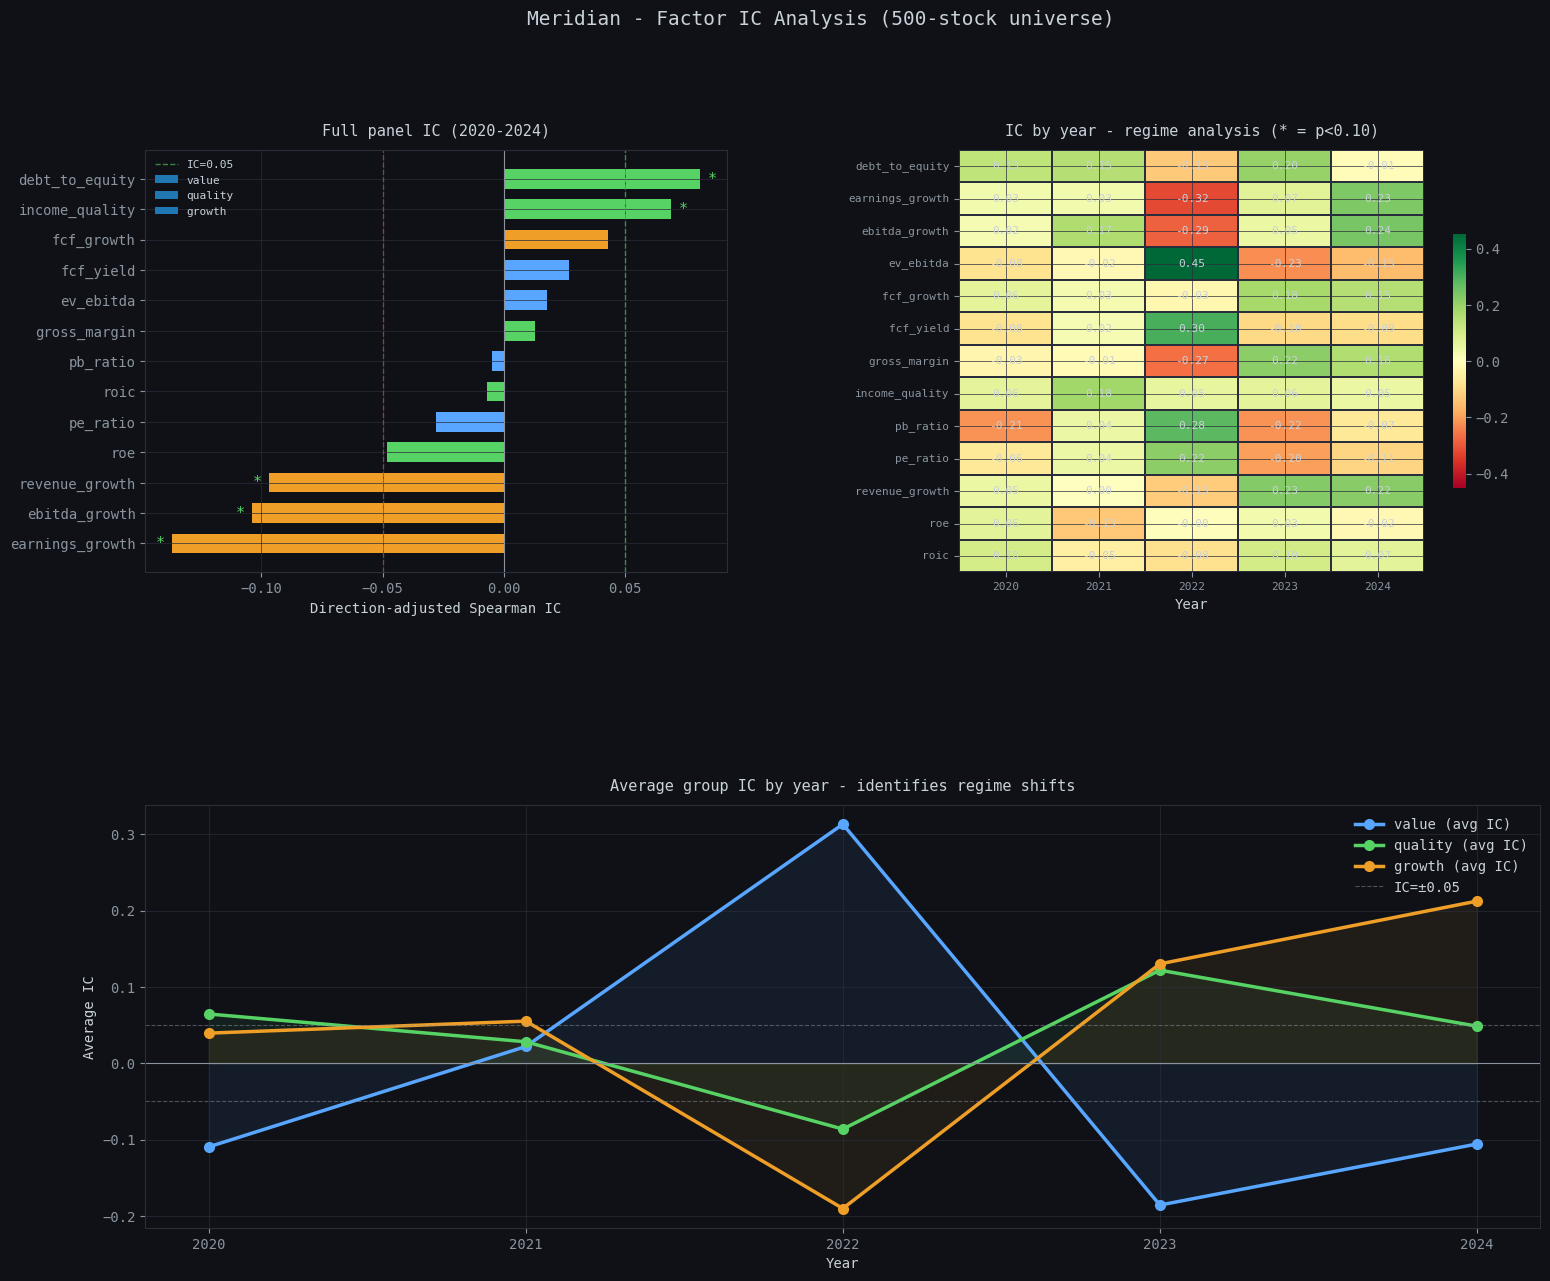

Saved: meridian_ic_analysis.png


In [46]:
group_colors = {'value': BLUE, 'quality': GREEN, 'growth': AMBER, 'other': MUTED}

with plt.rc_context(STYLE):
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.40)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    # ── Chart 1: Full panel IC bar ────────────────────────────────────────
    ic_f = ic_full.set_index('factor')
    colors = [group_colors.get(ic_f.loc[f, 'group'], MUTED)
              for f in ic_full['factor']]
    ax1.barh(ic_full['factor'][::-1], ic_full['ic'][::-1],
             color=colors[::-1], edgecolor='none', height=0.65)
    ax1.axvline(0,     color=MUTED,  linewidth=0.8)
    ax1.axvline(0.05,  color=GREEN,  linewidth=1.0, linestyle='--',
                alpha=0.6, label='IC=0.05')
    ax1.axvline(-0.05, color=RED,    linewidth=1.0, linestyle='--', alpha=0.4)
    # Mark significant factors
    for _, row in ic_full[ic_full['significant']].iterrows():
        y_pos = list(ic_full['factor'][::-1]).index(row['factor'])
        off = 0.003 if row['ic'] >= 0 else -0.003
        ax1.text(row['ic'] + off, y_pos, '*', fontsize=11, color=GREEN,
                 va='center', ha='left' if row['ic'] >= 0 else 'right')
    for grp, col in group_colors.items():
        if grp != 'other':
            ax1.barh([], [], color=col, label=grp)
    ax1.set_title('Full panel IC (2020-2024)', fontsize=11, pad=10)
    ax1.set_xlabel('Direction-adjusted Spearman IC')
    ax1.legend(framealpha=0, fontsize=8)

    # ── Chart 2: IC heatmap by year ───────────────────────────────────────
    if not ic_by_year_df.empty:
        vmax = max(ic_by_year_df.abs().max().max(), 0.01)
        sns.heatmap(
            ic_by_year_df.T,
            cmap='RdYlGn', center=0, vmin=-vmax, vmax=vmax,
            ax=ax2, annot=True, fmt='.2f',
            annot_kws={'size': 8, 'color': '#c9d1d9'},
            linewidths=0.3, linecolor='#2a2d3a',
            cbar_kws={'shrink': 0.6}
        )
        ax2.set_title('IC by year - regime analysis (* = p<0.10)',
                      fontsize=11, pad=10)
        ax2.tick_params(colors=MUTED, labelsize=8)
        ax2.set_xlabel('Year')
        ax2.set_ylabel('')

    # ── Chart 3: Group IC time series ─────────────────────────────────────
    if not ic_by_year_df.empty:
        for grp, factors in FACTOR_GROUPS.items():
            avail = [f for f in factors if f in ic_by_year_df.columns]
            if avail:
                grp_ic = ic_by_year_df[avail].mean(axis=1)
                col = group_colors.get(grp, MUTED)
                ax3.plot(grp_ic.index, grp_ic.values, color=col,
                         linewidth=2.5, marker='o', markersize=7,
                         label=f'{grp} (avg IC)')
                ax3.fill_between(grp_ic.index, grp_ic.values, 0,
                                 color=col, alpha=0.08)
        ax3.axhline(0,     color=MUTED, linewidth=0.8)
        ax3.axhline(0.05,  color=MUTED, linewidth=0.8,
                    linestyle='--', alpha=0.5, label='IC=±0.05')
        ax3.axhline(-0.05, color=MUTED, linewidth=0.8,
                    linestyle='--', alpha=0.5)
        ax3.set_title(
            'Average group IC by year - identifies regime shifts',
            fontsize=11, pad=10)
        ax3.set_xlabel('Year')
        ax3.set_ylabel('Average IC')
        ax3.legend(framealpha=0)
        ax3.set_xticks(ic_by_year_df.index)

    fig.suptitle(
        'Meridian - Factor IC Analysis (500-stock universe)',
        fontsize=14, y=0.98)
    plt.savefig('meridian_ic_analysis.png', dpi=150,
                bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print('Saved: meridian_ic_analysis.png')

## Cell 8 - XGBoost feature importance

30 iterations to stabilise importances across random seeds.
Cross-validated R² reported as a model quality sanity check (low is expected - factor models explain a small fraction of return variance).

In [47]:
X = panel_clean[factor_cols].copy()
y = panel_clean['fwd_return'].copy()

# Winsorise - tighter bounds for growth factors
for col in factor_cols:
    is_growth = col in FACTOR_GROUPS.get('growth', [])
    lo_q, hi_q = (0.10, 0.90) if is_growth else (0.05, 0.95)
    lo, hi = X[col].quantile(lo_q), X[col].quantile(hi_q)
    X[col] = X[col].clip(lo, hi)

X = X.fillna(X.median())

print(f'Training XGBoost: {len(X)} obs x {len(factor_cols)} factors')
print('Running 30 iterations...\n')

importance_values = np.zeros(len(factor_cols))

for i in tqdm(range(30)):
    model = XGBRegressor(
        n_jobs=-1, verbosity=0, random_state=i,
        n_estimators=200, max_depth=3,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
    )
    model.fit(X.values, y.values)
    importance_values += model.feature_importances_ / 30

xgb_fi = pd.DataFrame({
    'factor':     factor_cols,
    'importance': importance_values,
    'group':      [next((g for g, fs in FACTOR_GROUPS.items()
                         if f in fs), 'other')
                   for f in factor_cols],
}).sort_values('importance', ascending=False).reset_index(drop=True)

total_imp = xgb_fi['importance'].sum()
xgb_fi['normalized'] = xgb_fi['importance'] / total_imp
xgb_fi['cumulative'] = xgb_fi['normalized'].cumsum()

print('\nXGBoost importances:\n')
print(xgb_fi[['factor','group','normalized','cumulative']]
      .round(3).to_string(index=False))

# Cross-validated R²
cv_scores = cross_val_score(
    XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                 subsample=0.8, random_state=42, verbosity=0),
    X.values, y.values, cv=5, scoring='r2'
)
print(f'\nCV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('(Low R² is expected - factor models explain ~2-5% of return variance)')

Training XGBoost: 715 obs x 13 factors
Running 30 iterations...



100%|██████████| 30/30 [00:01<00:00, 26.66it/s]



XGBoost importances:

         factor   group  normalized  cumulative
      fcf_yield   value       0.118       0.118
       pb_ratio   value       0.116       0.234
            roe quality       0.088       0.321
           roic quality       0.085       0.406
       pe_ratio   value       0.072       0.478
 revenue_growth  growth       0.069       0.547
  ebitda_growth  growth       0.067       0.614
      ev_ebitda   value       0.067       0.680
earnings_growth  growth       0.066       0.746
   gross_margin quality       0.065       0.812
 debt_to_equity quality       0.065       0.876
 income_quality quality       0.063       0.939
     fcf_growth  growth       0.061       1.000

CV R²: -0.6747 ± 0.6012
(Low R² is expected - factor models explain ~2-5% of return variance)


## Cell 9 - Method comparison

In [48]:
ic_indexed  = ic_full.set_index('factor')[['ic', 'p_value', 'group']]
xgb_indexed = xgb_fi.set_index('factor')[['normalized']]

comparison = ic_indexed.join(xgb_indexed, how='outer').fillna(0)
comparison['ic_rank']  = comparison['ic'].rank(ascending=False)
comparison['xgb_rank'] = comparison['normalized'].rank(ascending=False)
comparison['rank_diff'] = (comparison['ic_rank'] - comparison['xgb_rank']).abs()
comparison['agree'] = comparison['rank_diff'] <= 3
comparison = comparison.sort_values('ic', ascending=False)

print('── IC vs XGBoost comparison ──\n')
print(comparison.round(3).to_string())

print('\n── High-confidence factors (IC > 0 AND methods agree) ──')
high_conf = comparison[
    (comparison['ic'] > 0.02) & (comparison['agree'])
].index.tolist()
print(high_conf)

print('\n── Weak/conflicting factors (consider reducing weight) ──')
weak = comparison[
    (comparison['ic'] <= 0) | (comparison['rank_diff'] > 5)
].index.tolist()
print(weak)

── IC vs XGBoost comparison ──

                    ic  p_value    group  normalized  ic_rank  xgb_rank  rank_diff  agree
factor                                                                                   
debt_to_equity   0.081    0.030  quality       0.065      1.0      11.0       10.0  False
income_quality   0.069    0.066  quality       0.063      2.0      12.0       10.0  False
fcf_growth       0.043    0.255   growth       0.061      3.0      13.0       10.0  False
fcf_yield        0.027    0.476    value       0.118      4.0       1.0        3.0   True
ev_ebitda        0.018    0.651    value       0.067      5.0       8.0        3.0   True
gross_margin     0.013    0.731  quality       0.065      6.0      10.0        4.0  False
pb_ratio        -0.005    0.894    value       0.116      7.0       2.0        5.0  False
roic            -0.007    0.855  quality       0.085      8.0       4.0        4.0  False
pe_ratio        -0.028    0.466    value       0.072      9.0       

## Cell 10 - Derive revised GROUP_WEIGHTS

In [49]:
# Blend alpha: how much to trust empirical IC vs the prior
# With ~500 stocks this is higher confidence than the 30-ticker version
BLEND_ALPHA = 0.50  # 50% data-driven, 50% prior

# IC-based factor weights (floor negative IC at 0)
ic_factor_weights = {}
for factor in factor_cols:
    ic_val = ic_indexed.loc[factor, 'ic'] if factor in ic_indexed.index else 0.0
    ic_factor_weights[factor] = max(float(ic_val), 0.0)

total_ic = sum(ic_factor_weights.values())
if total_ic > 0:
    ic_factor_weights = {k: v / total_ic for k, v in ic_factor_weights.items()}

# Aggregate to group level
ic_group_weights = {}
for grp, factors in FACTOR_GROUPS.items():
    ic_group_weights[grp] = sum(ic_factor_weights.get(f, 0.0) for f in factors)
ic_group_weights['momentum'] = 0.0  # momentum from prices, not in panel

group_total = sum(ic_group_weights.values())
if group_total > 0:
    ic_group_weights = {k: v / group_total for k, v in ic_group_weights.items()}

# Blended weights
blended = {}
for grp in FIXED_WEIGHTS:
    ic_w    = ic_group_weights.get(grp, 0.0)
    fixed_w = FIXED_WEIGHTS[grp]
    blended[grp] = BLEND_ALPHA * ic_w + (1 - BLEND_ALPHA) * fixed_w

blend_total = sum(blended.values())
blended = {k: v / blend_total for k, v in blended.items()}

print('=' * 60)
print('REVISED GROUP_WEIGHTS - paste into factors.py (both projects)')
print('=' * 60)
print()
print(f'# Derived from {len(panel_clean)} obs across {len(SNAPSHOT_DATES)} years')
print(f'# Blend: {BLEND_ALPHA:.0%} IC-derived + {1-BLEND_ALPHA:.0%} prior')
print()
print('GROUP_WEIGHTS = {')
for grp, weight in blended.items():
    bar = chr(9608) * int(weight * 40)
    print(f'    "{grp}": {weight:.3f},   # {bar}')
print('}')
print()
print('Pure IC:  ', '  '.join(f'{g}={w:.3f}' for g,w in ic_group_weights.items()))
print('Blended:  ', '  '.join(f'{g}={w:.3f}' for g,w in blended.items()))
print('Fixed:    ', '  '.join(f'{g}={w:.3f}' for g,w in FIXED_WEIGHTS.items()))

REVISED GROUP_WEIGHTS - paste into factors.py (both projects)

# Derived from 715 obs across 5 years
# Blend: 50% IC-derived + 50% prior

GROUP_WEIGHTS = {
    "value": 0.240,   # █████████
    "quality": 0.475,   # ██████████████████
    "growth": 0.186,   # ███████
    "momentum": 0.100,   # ████
}

Pure IC:   value=0.179  quality=0.649  growth=0.171  momentum=0.000
Blended:   value=0.240  quality=0.475  growth=0.186  momentum=0.100
Fixed:     value=0.300  quality=0.300  growth=0.200  momentum=0.200


## Cell 11 - Final comparison charts

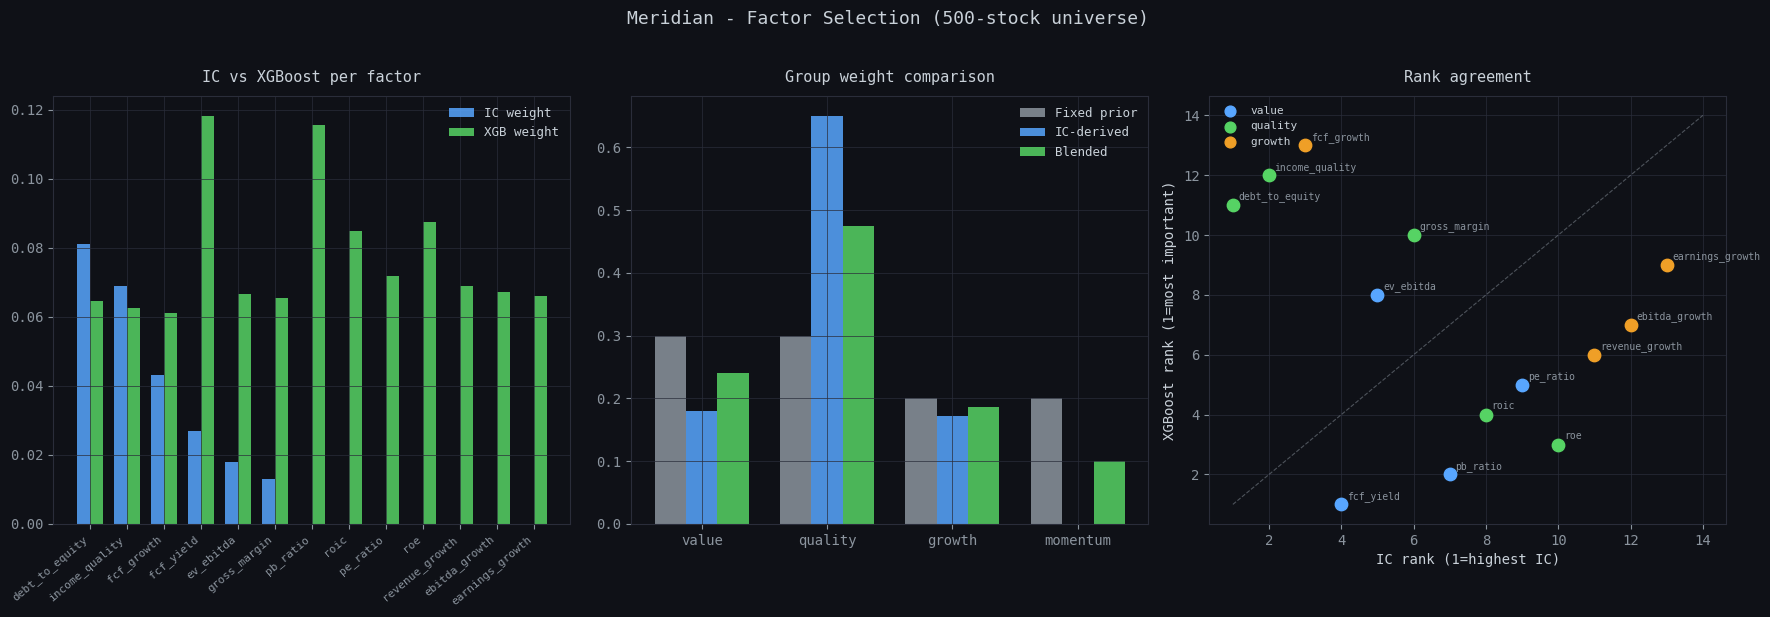

Saved: meridian_factor_selection.png

Done. Copy GROUP_WEIGHTS from Cell 10 into factors.py and re-run backtest.


In [50]:
with plt.rc_context(STYLE):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ── Chart 1: IC vs XGBoost grouped bar ───────────────────────────────
    ax = axes[0]
    fsorted = comparison.sort_values('ic', ascending=False).index.tolist()
    x = np.arange(len(fsorted))
    w = 0.35
    ic_vals  = [max(float(comparison.loc[f, 'ic']), 0) for f in fsorted]
    xgb_vals = [float(comparison.loc[f, 'normalized'])  for f in fsorted]
    xgb_norm = np.array(xgb_vals) / max(sum(xgb_vals), 1e-9)
    ax.bar(x - w/2, ic_vals,  w, label='IC weight',
           color=BLUE,  alpha=0.85, edgecolor='none')
    ax.bar(x + w/2, xgb_norm, w, label='XGB weight',
           color=GREEN, alpha=0.85, edgecolor='none')
    ax.set_xticks(x)
    ax.set_xticklabels(fsorted, rotation=40, ha='right', fontsize=8)
    ax.set_title('IC vs XGBoost per factor', fontsize=11, pad=10)
    ax.legend(framealpha=0, fontsize=9)

    # ── Chart 2: Group weight comparison ─────────────────────────────────
    ax = axes[1]
    groups = list(FIXED_WEIGHTS.keys())
    x = np.arange(len(groups))
    w = 0.25
    ax.bar(x - w, [FIXED_WEIGHTS[g]              for g in groups],
           w, label='Fixed prior', color=MUTED, alpha=0.85, edgecolor='none')
    ax.bar(x,     [ic_group_weights.get(g, 0)    for g in groups],
           w, label='IC-derived',  color=BLUE,  alpha=0.85, edgecolor='none')
    ax.bar(x + w, [blended[g]                    for g in groups],
           w, label='Blended',     color=GREEN, alpha=0.85, edgecolor='none')
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=10)
    ax.set_title('Group weight comparison', fontsize=11, pad=10)
    ax.legend(framealpha=0, fontsize=9)

    # ── Chart 3: Rank agreement scatter ──────────────────────────────────
    ax = axes[2]
    for factor, row in comparison.iterrows():
        col = group_colors.get(row['group'], MUTED)
        ax.scatter(row['ic_rank'], row['xgb_rank'],
                   color=col, s=80, zorder=3)
        ax.annotate(factor, (row['ic_rank'], row['xgb_rank']),
                    fontsize=7, color=MUTED,
                    xytext=(4, 4), textcoords='offset points')
    max_r = len(comparison) + 1
    ax.plot([1, max_r], [1, max_r], color=MUTED,
            linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('IC rank (1=highest IC)')
    ax.set_ylabel('XGBoost rank (1=most important)')
    ax.set_title('Rank agreement', fontsize=11, pad=10)
    for grp, col in group_colors.items():
        if grp != 'other':
            ax.scatter([], [], color=col, s=60, label=grp)
    ax.legend(framealpha=0, fontsize=8)

    fig.suptitle(
        'Meridian - Factor Selection (500-stock universe)',
        fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('meridian_factor_selection.png', dpi=150,
                bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print('Saved: meridian_factor_selection.png')

print('\nDone. Copy GROUP_WEIGHTS from Cell 10 into factors.py and re-run backtest.')